Phase 1: Train 3-Class CNN for Audio-based Conversation Detection

Phase 1: Train 3-Class CNN for Audio-based Conversation Detection
Dataset format:
 - 1 CSV file = 1 sample
 - each CSV shape = (128, 120)
 - label is parsed from filename

Example filename:
   group_study_0_2.csv
 This notebook assumes the LAST integer before ".csv" is the class label.
 Example:
   group_study_0_2.csv -> label = 2

 Classes:
   0 = background noise
   1 = other speech
   2 = conversation

Section 2 Import Libraries

In [1]:
from __future__ import annotations

import os
import re
import random
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
)

Section 3  Configuration

In [2]:
# =========================
# CONFIG
# =========================
DATA_DIR = r"C:\Users\66617\Desktop\PublicDataSet\audio_imu_conversational_data\audio_features" # root folder containing CSV files
OUTPUT_DIR = r"C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs" # output folder

INPUT_HEIGHT = 128
INPUT_WIDTH = 120
INPUT_CHANNELS = 1
NUM_CLASSES = 3

# TEST_SIZE = 0.20  # not used in LOGO evaluation
RANDOM_SEED = 42
BATCH_SIZE = 32
EPOCHS = 20 #เปลี่ยนเพื่อเทสได้เร็วขึ้น
LEARNING_RATE = 1e-3

MODEL_NAME = "conversation_cnn_3class"
KERAS_MODEL_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.keras")
TFLITE_MODEL_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.tflite")
TRAINING_CURVE_PATH = os.path.join(OUTPUT_DIR, "training_curve.png")
CONFUSION_MATRIX_PATH = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
CLASSIFICATION_REPORT_PATH = os.path.join(OUTPUT_DIR, "classification_report.txt")
CONFIG_SAVE_PATH = os.path.join(OUTPUT_DIR, "run_config.txt")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

CONFUSION_MATRIX_PATH = os.path.join(PLOT_DIR, "confusion_matrix_all_folds.png")
METRICS_BAR_PATH = os.path.join(PLOT_DIR, "metrics_bar_all_folds.png")
FOLD_F1_PATH = os.path.join(PLOT_DIR, "macro_f1_per_fold.png")
FINAL_REPORT_PATH = os.path.join(REPORT_DIR, "classification_report_all_folds.txt")
FINAL_METRICS_PATH = os.path.join(REPORT_DIR, "final_metrics_all_folds.txt")
RESULTS_DF_PATH = os.path.join(REPORT_DIR, "fold_results.csv")

Section 4 Reproducibility

In [3]:
# =========================
# REPRODUCIBILITY
# =========================
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(RANDOM_SEED)

Section 5 Label Parsing Function

In [4]:
def parse_label_from_filename(file_path: Path) -> int:
    """
    Expected filename pattern:
        <anything>_<index>_<label>.csv
    Example:
        group_study_0_2.csv -> label = 2
    """
    name = file_path.stem
    parts = name.split("_")

    if len(parts) < 3:
        raise ValueError(f"Filename format not supported: {file_path.name}")

    try:
        label = int(parts[-1])
    except ValueError:
        raise ValueError(f"Cannot parse label from filename: {file_path.name}")

    if label not in {0, 1, 2}:
        raise ValueError(
            f"Parsed label={label} from {file_path.name}, but expected one of {{0,1,2}}"
        )

    return label

In [5]:
def extract_participant_id(file_path: Path) -> str:
    """
    Example:
    .../audio_features/p3/feat_30sec/file.csv -> 'p3'
    """
    for part in file_path.parts:
        if re.fullmatch(r"p\d+", part):
            return part

    raise ValueError(f"Cannot find participant ID in path: {file_path}")

Section 6  Find CSV Files

In [6]:
# =========================
# FILE DISCOVERY
# =========================
def find_all_csv_files(data_dir: str) -> List[Path]:
    data_path = Path(data_dir)

    if not data_path.exists():
        raise FileNotFoundError(f"DATA_DIR does not exist: {data_dir}")

    csv_files = sorted(data_path.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found under: {data_dir}")

    return csv_files

Section 7  Load Single CSV Sample

In [7]:
# =========================
# CSV LOADING
# =========================
def load_single_csv_feature(file_path: Path) -> np.ndarray:
    """
    Load one CSV sample.
    Expected shape: (128, 120)
    """
    feature = pd.read_csv(file_path, header=None).values.astype(np.float32)

    if feature.shape != (INPUT_HEIGHT, INPUT_WIDTH):
        raise ValueError(
            f"Invalid shape for {file_path.name}: got {feature.shape}, "
            f"expected ({INPUT_HEIGHT}, {INPUT_WIDTH})"
        )

    return feature

Section 8  Load Full Dataset

In [8]:
def load_dataset(data_dir: str) -> Tuple[np.ndarray, np.ndarray, List[str], np.ndarray]:
    """
    Load all CSV files into:
        X: (N, 128, 120)
        y: (N,)
        groups: participant IDs such as p1, p2, p3
    """
    csv_files = find_all_csv_files(data_dir)

    features = []
    labels = []
    filenames = []
    groups = []

    for file_path in csv_files:
        try:
            x = load_single_csv_feature(file_path)
            y = parse_label_from_filename(file_path)
            g = extract_participant_id(file_path)

            features.append(x)
            labels.append(y)
            filenames.append(str(file_path))
            groups.append(g)

        except Exception as e:
            print(f"[SKIP] {file_path} -> {e}")

    if not features:
        raise RuntimeError("No valid samples loaded. Check file naming and CSV shapes.")

    X = np.stack(features, axis=0).astype(np.float32)
    y = np.array(labels, dtype=np.int32)
    groups = np.array(groups, dtype=str)

    return X, y, filenames, groups

Section 9 Load and Inspect Dataset

In [9]:
X, y, filenames, groups = load_dataset(DATA_DIR)

print("[INFO] Loaded samples:", len(X))
print("[INFO] Raw X shape:", X.shape)
print("[INFO] y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)
print("\n[INFO] Class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt}")

print("\n[INFO] Groups:", np.unique(groups))

[INFO] Loaded samples: 1691
[INFO] Raw X shape: (1691, 128, 120)
[INFO] y shape: (1691,)

[INFO] Class distribution:
Class 0: 389
Class 1: 589
Class 2: 713

[INFO] Groups: ['p10' 'p11' 'p12' 'p13' 'p14' 'p15' 'p16' 'p17' 'p18' 'p19' 'p20' 'p21'
 'p22' 'p23' 'p24' 'p3' 'p4' 'p5' 'p6' 'p7' 'p8' 'p9']


Section 10  Reshape 

In [10]:
# =========================
# PREPROCESSING
# =========================
def reshape_for_cnn(X: np.ndarray) -> np.ndarray:
    """
    Convert:
        (N, 128, 120) -> (N, 128, 120, 1)
    """
    return np.expand_dims(X, axis=-1).astype(np.float32)

X = reshape_for_cnn(X)
print("[INFO] Reshaped X for CNN:", X.shape)

[INFO] Reshaped X for CNN: (1691, 128, 120, 1)


Section 11 Train/Test Split

In [11]:
def normalize_train_test(X_train, X_test):
    mean = np.mean(X_train, axis=(0,1,2), keepdims=True)
    std = np.std(X_train, axis=(0,1,2), keepdims=True) + 1e-8
    return (X_train - mean)/std, (X_test - mean)/std, mean, std


In [12]:
def build_cnn_lstm_stable():
    inputs = tf.keras.layers.Input(shape=(128, 120, 1))

    # CNN feature extractor
    x = tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,1))(x)

    x = tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,1))(x)

    x = tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # เพิ่ม feature extractor
    x = tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)

    # reshape to sequence
    x = tf.keras.layers.Permute((2,1,3))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)

    x = tf.keras.layers.Dropout(0.4)(x)

    # deeper temporal modeling
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)
    )(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)
    )(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # classifier
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="conversation_cnn_lstm_stable_v3")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [13]:
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

    if 2 in class_weights:
        class_weights[2] *= 1.2 #1.8

    return class_weights

In [14]:
def train_model(model, X_train, y_train, validation_split=0.1):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    class_weights = get_class_weights(y_train)
    class_weights = {
        0: 1.0,
        1: 4.0,   # 🔥 ดัน other_speech
        2: 3.0 # 2.5
    }

    print("Class weights:", class_weights)

    history = model.fit(
        X_train,
        y_train,
        validation_split=validation_split,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )
    return history

Section 12  รวมการ normalize, build model, train, evaluate

เวอร์ชั้นทดสอบ Epoch=20, Fold=5

In [ ]:
logo = LeaveOneGroupOut()

fold_results = []
last_model = None
last_history = None
last_y_test = None
last_y_pred = None
all_y_true = []
all_y_pred = []
max_folds = 5

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    if fold_idx > max_folds:
        break

    print(f"\n===== FOLD {fold_idx} =====")
    print(f"Test group: {groups[test_idx][0]}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # normalize using train only
    X_train, X_test, norm_mean, norm_std = normalize_train_test(X_train, X_test)

    # build model
    model = build_cnn_lstm_stable()

    # train
    history = train_model(model, X_train, y_train, validation_split=0.1)

    # predict
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    acc = accuracy_score(y_test, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall   : {recall_macro:.4f}")
    print(f"Macro F1       : {f1_macro:.4f}")

    report = classification_report(
        y_test,
        y_pred,
        target_names=["background_noise", "other_speech", "conversation"],
        digits=4,
        zero_division=0
    )
    print(report)

    fold_results.append({
        "fold": fold_idx,
        "test_group": groups[test_idx][0],
        "accuracy": acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
    })

    last_model = model
    last_history = history
    last_y_test = y_test
    last_y_pred = y_pred

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# ===== FINAL TRAIN ON FULL DATA =====
X_full = X.copy()
y_full = y.copy()

mean = np.mean(X_full, axis=(0,1,2), keepdims=True)
std = np.std(X_full, axis=(0,1,2), keepdims=True) + 1e-8
X_full = (X_full - mean) / std

final_model = build_cnn_lstm_stable()
final_history = train_model(final_model, X_full, y_full, validation_split=0.1)

final_model.save(os.path.join(OUTPUT_DIR, "final_model.keras"))
np.save(os.path.join(OUTPUT_DIR, "norm_mean.npy"), mean)
np.save(os.path.join(OUTPUT_DIR, "norm_std.npy"), std)

print("Saved final_model + norm_mean + norm_std")

ทดสอบเวอร์ชัน full run Epoch=20 จำนวน group จริงทั้งหมดใน LOGO

In [15]:
logo = LeaveOneGroupOut()

fold_results = []
last_model = None
last_history = None
last_y_test = None
last_y_pred = None
all_y_true = []
all_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    print(f"\n===== FOLD {fold_idx} =====")
    print(f"Test group: {groups[test_idx][0]}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # normalize using train only
    X_train, X_test, norm_mean, norm_std = normalize_train_test(X_train, X_test)

    # build model
    model = build_cnn_lstm_stable()

    # train
    history = train_model(model, X_train, y_train, validation_split=0.1)

    # predict
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    acc = accuracy_score(y_test, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall   : {recall_macro:.4f}")
    print(f"Macro F1       : {f1_macro:.4f}")

    report = classification_report(
        y_test,
        y_pred,
        target_names=["background_noise", "other_speech", "conversation"],
        digits=4,
        zero_division=0
    )
    print(report)

    fold_results.append({
        "fold": fold_idx,
        "test_group": groups[test_idx][0],
        "accuracy": acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
    })

    last_model = model
    last_history = history
    last_y_test = y_test
    last_y_pred = y_pred

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# ===== FINAL TRAIN ON FULL DATA =====
X_full = X.copy()
y_full = y.copy()

mean = np.mean(X_full, axis=(0,1,2), keepdims=True)
std = np.std(X_full, axis=(0,1,2), keepdims=True) + 1e-8
X_full = (X_full - mean) / std

final_model = build_cnn_lstm_stable()
final_history = train_model(final_model, X_full, y_full, validation_split=0.1)

final_model.save(os.path.join(OUTPUT_DIR, "final_model.keras"))
np.save(os.path.join(OUTPUT_DIR, "norm_mean.npy"), mean)
np.save(os.path.join(OUTPUT_DIR, "norm_std.npy"), std)

print("Saved final_model + norm_mean + norm_std")


===== FOLD 1 =====
Test group: p10


Class weights: {0: 1.0, 1: 4.0, 2: 3.0}
Epoch 1/20


46/46 [==============================] - 88s 2s/step - loss: 2.3735 - accuracy: 0.5142 - val_loss: 1.3408 - val_accuracy: 0.4720 - lr: 0.0010
Epoch 2/20
46/46 [==============================] - 63s 1s/step - loss: 1.9656 - accuracy: 0.6545 - val_loss: 0.9090 - val_accuracy: 0.6025 - lr: 0.0010
Epoch 3/20
46/46 [==============================] - 64s 1s/step - loss: 1.7457 - accuracy: 0.7015 - val_loss: 0.7799 - val_accuracy: 0.5528 - lr: 0.0010
Epoch 4/20
46/46 [==============================] - 63s 1s/step - loss: 1.6147 - accuracy: 0.7339 - val_loss: 1.1068 - val_accuracy: 0.3727 - lr: 0.0010
Epoch 5/20
46/46 [==============================] - 64s 1s/step - loss: 1.4705 - accuracy: 0.7657 - val_loss: 0.8545 - val_accuracy: 0.5280 - lr: 0.0010
Epoch 6/20
46/46 [==============================] - 64s 1s/step - loss: 1.3550 - accuracy: 0.8030 - val_loss: 1.1614 - val_accuracy: 0.4161 - lr: 0.0010
Ep

Section 14 — Model Summary

In [16]:
results_df = pd.DataFrame(fold_results)
print(results_df)

print("\n===== FINAL LOGO RESULT =====")
print(f"Mean Accuracy       : {results_df['accuracy'].mean():.4f}")
print(f"Mean Macro Precision: {results_df['macro_precision'].mean():.4f}")
print(f"Mean Macro Recall   : {results_df['macro_recall'].mean():.4f}")
print(f"Mean Macro F1       : {results_df['macro_f1'].mean():.4f}")

    fold test_group  accuracy  macro_precision  macro_recall  macro_f1
0      1        p10  0.795181         0.741219      0.704009  0.696806
1      2        p11  0.697368         0.496169      0.629167  0.552621
2      3        p12  0.815789         0.860203      0.868056  0.839752
3      4        p13  0.465116         0.342742      0.472371  0.391002
4      5        p14  0.755814         0.774350      0.758838  0.762930
5      6        p15  0.820513         0.869697      0.824763  0.831704
6      7        p16  0.589744         0.750327      0.579295  0.579879
7      8        p17  0.654762         0.695125      0.659483  0.658180
8      9        p18  0.595238         0.633333      0.598513  0.563263
9     10        p19  0.518987         0.543316      0.602614  0.521776
10    11        p20  0.734177         0.804938      0.736695  0.751593
11    12        p21  0.816901         0.807778      0.806587  0.806996
12    13        p22  0.619718         0.799320      0.687500  0.635185
13    

In [17]:
print("\n=== MODEL SUMMARY ===")
last_model.summary()


=== MODEL SUMMARY ===
Model: "conversation_cnn_lstm_stable_v3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_22 (InputLayer)       [(None, 128, 120, 1)]     0         
                                                                 
 conv2d_84 (Conv2D)          (None, 128, 120, 32)      320       
                                                                 
 batch_normalization_84 (Ba  (None, 128, 120, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_63 (MaxPooli  (None, 64, 120, 32)       0         
 ng2D)                                                           
                                                                 
 conv2d_85 (Conv2D)          (None, 64, 120, 64)       18496     
                                                                 
 batch_norma

Section 18 — Plot Training Curve

In [18]:
def plot_training_curve(history: tf.keras.callbacks.History, save_path: str) -> None:
    hist = history.history

    plt.figure(figsize=(10, 4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")

    plt.title("Training Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=200)
    plt.show()

Section 19 — Plot Confusion Matrix

In [19]:
def save_confusion_matrix(y_true, y_pred, save_path):
    cm = confusion_matrix(y_true, y_pred)
    class_names = ["background_noise", "other_speech", "conversation"]

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Confusion Matrix (All Folds)")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=20)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    plt.savefig(save_path, dpi=200)
    plt.close()

In [20]:
save_confusion_matrix(all_y_true, all_y_pred, CONFUSION_MATRIX_PATH)
print(f"[INFO] Saved confusion matrix to: {CONFUSION_MATRIX_PATH}")

[INFO] Saved confusion matrix to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\confusion_matrix_all_folds.png


In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix_final(y_true, y_pred, save_path):
    cm = confusion_matrix(y_true, y_pred)

    class_names = ["background_noise", "other_speech", "conversation"]

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="viridis")
    plt.title("Confusion Matrix (All Folds)")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=20)
    plt.yticks(tick_marks, class_names)

    # ใส่ตัวเลขในช่อง
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center", color="black")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    # ✅ เซฟอย่างเดียว (ไม่ show)
    plt.savefig(save_path, dpi=200)
    plt.close()

In [22]:
plot_confusion_matrix_final(
    all_y_true,
    all_y_pred,
    CONFUSION_MATRIX_PATH
)
print(f"[INFO] Saved confusion matrix to: {CONFUSION_MATRIX_PATH}")

[INFO] Saved confusion matrix to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\confusion_matrix_all_folds.png


Section D — Save Final Metrics only

In [23]:
def save_final_metrics_file(y_true, y_pred, save_path):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    lines = [
        "=== FINAL METRICS (ALL FOLDS) ===",
        f"Accuracy       : {acc:.6f}",
        f"Macro Precision: {precision:.6f}",
        f"Macro Recall   : {recall:.6f}",
        f"Macro F1       : {f1:.6f}",
    ]

    with open(save_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

In [24]:
save_final_metrics_file(all_y_true, all_y_pred, FINAL_METRICS_PATH)
print(f"[INFO] Saved final metrics to: {FINAL_METRICS_PATH}")

[INFO] Saved final metrics to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\reports\final_metrics_all_folds.txt


Section E — Save Metrics Bar Plot only

In [25]:
def save_metrics_bar_plot(y_true, y_pred, save_path):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    names = ["Accuracy", "Precision", "Recall", "F1"]
    values = [acc, precision, recall, f1]

    plt.figure(figsize=(6, 4))
    plt.bar(names, values)
    plt.ylim(0, 1)
    plt.title("Model Performance (All Folds)")

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

In [26]:
save_metrics_bar_plot(all_y_true, all_y_pred, METRICS_BAR_PATH)
print(f"[INFO] Saved metrics bar plot to: {METRICS_BAR_PATH}")

[INFO] Saved metrics bar plot to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\metrics_bar_all_folds.png


Section F — Save Fold Results CSV

In [27]:
results_df = pd.DataFrame(fold_results)
results_df.to_csv(RESULTS_DF_PATH, index=False, encoding="utf-8")
print(f"[INFO] Saved fold results to: {RESULTS_DF_PATH}")

[INFO] Saved fold results to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\reports\fold_results.csv


Section G — Save Fold-wise Macro F1 Plot only

In [28]:
def save_fold_f1_plot(results_df, save_path):
    plt.figure(figsize=(10, 4))
    plt.plot(results_df["macro_f1"].values, marker="o")
    plt.title("Macro F1 per Fold")
    plt.xlabel("Fold")
    plt.ylabel("Macro F1")
    plt.grid()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

In [29]:
save_fold_f1_plot(results_df, FOLD_F1_PATH)
print(f"[INFO] Saved fold-wise Macro F1 plot to: {FOLD_F1_PATH}")

[INFO] Saved fold-wise Macro F1 plot to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\macro_f1_per_fold.png


Section H — Final Output Summary

In [30]:
print("\n[INFO] All outputs saved.")
print(f"[INFO] Confusion matrix path     : {CONFUSION_MATRIX_PATH}")
print(f"[INFO] Metrics bar plot path    : {METRICS_BAR_PATH}")
print(f"[INFO] Fold F1 plot path        : {FOLD_F1_PATH}")
print(f"[INFO] Classification report    : {FINAL_REPORT_PATH}")
print(f"[INFO] Final metrics file       : {FINAL_METRICS_PATH}")
print(f"[INFO] Fold results CSV         : {RESULTS_DF_PATH}")


[INFO] All outputs saved.
[INFO] Confusion matrix path     : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\confusion_matrix_all_folds.png
[INFO] Metrics bar plot path    : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\metrics_bar_all_folds.png
[INFO] Fold F1 plot path        : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\macro_f1_per_fold.png
[INFO] Classification report    : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\reports\classification_report_all_folds.txt
[INFO] Final metrics file       : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\reports\final_metrics_all_folds.txt
[INFO] Fold results 

Section C2 — Metric Summary (ใช้เขียน thesis)

In [31]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc = accuracy_score(all_y_true, all_y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_y_true,
    all_y_pred,
    average="macro",
    zero_division=0
)

print("\n=== FINAL METRICS (ALL FOLDS) ===")
print(f"Accuracy       : {acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1       : {f1:.4f}")


=== FINAL METRICS (ALL FOLDS) ===
Accuracy       : 0.6546
Macro Precision: 0.6982
Macro Recall   : 0.6841
Macro F1       : 0.6750


Section C3 — Bar Plot Metrics (visual สำหรับ thesis)

In [32]:
def plot_metrics_bar(acc, precision, recall, f1, save_path):
    names = ["Accuracy", "Precision", "Recall", "F1"]
    values = [acc, precision, recall, f1]

    plt.figure(figsize=(6,4))
    plt.bar(names, values)
    plt.ylim(0,1)
    plt.title("Model Performance (All Folds)")

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

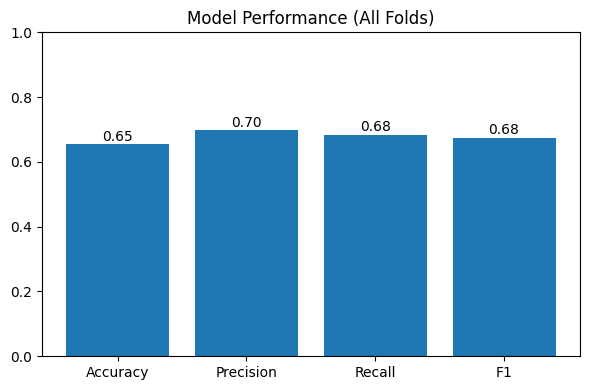

In [33]:
plot_metrics_bar(
    acc,
    precision,
    recall,
    f1,
    os.path.join(OUTPUT_DIR, "metrics_bar.png")
)

Section เสริม (แนะนำมาก) — Fold-wise plot

In [34]:
def plot_fold_f1(results_df):
    plt.figure(figsize=(10,4))
    plt.plot(results_df["macro_f1"], marker="o")
    plt.title("Macro F1 per Fold")
    plt.xlabel("Fold")
    plt.ylabel("Macro F1")
    plt.grid()
    plt.show()

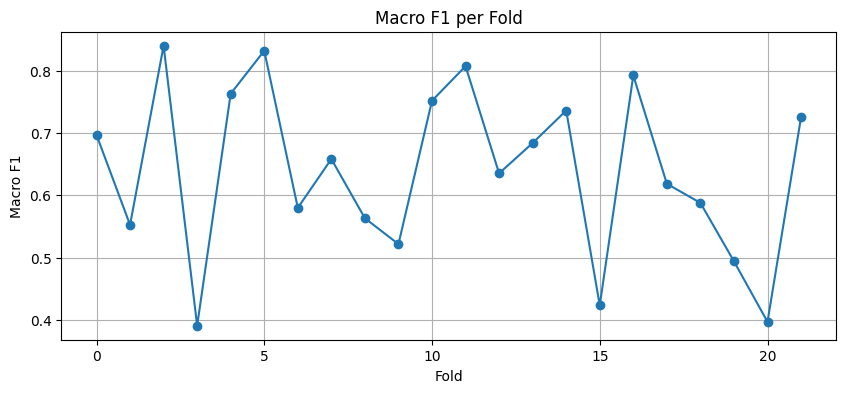

In [35]:
plot_fold_f1(results_df)

Section 21 — Save Run Configuration

In [36]:
def save_run_config(
    save_path: str,
    data_dir: str,
    output_dir: str,
    total_shape: Tuple[int, ...],
    groups: np.ndarray,
    mean_macro_f1: float,
    mean_accuracy: float
) -> None:
    lines = [
        "=== RUN CONFIG ===",
        f"DATA_DIR = {data_dir}",
        f"OUTPUT_DIR = {output_dir}",
        f"INPUT_SHAPE = ({INPUT_HEIGHT}, {INPUT_WIDTH}, {INPUT_CHANNELS})",
        f"NUM_CLASSES = {NUM_CLASSES}",
        f"EVALUATION = LeaveOneGroupOut",
        f"NUM_GROUPS = {len(np.unique(groups))}",
        f"GROUPS = {list(np.unique(groups))}",
        f"RANDOM_SEED = {RANDOM_SEED}",
        f"BATCH_SIZE = {BATCH_SIZE}",
        f"EPOCHS = {EPOCHS}",
        f"LEARNING_RATE = {LEARNING_RATE}",
        f"TOTAL_DATA_SHAPE = {total_shape}",
        f"MEAN_ACCURACY = {mean_accuracy:.6f}",
        f"MEAN_MACRO_F1 = {mean_macro_f1:.6f}",
        f"KERAS_MODEL_PATH = {KERAS_MODEL_PATH}",
        f"TFLITE_MODEL_PATH = {TFLITE_MODEL_PATH}",
        f"TRAINING_CURVE_PATH = {TRAINING_CURVE_PATH}",
        f"CONFUSION_MATRIX_PATH = {CONFUSION_MATRIX_PATH}",
        f"CLASSIFICATION_REPORT_PATH = {CLASSIFICATION_REPORT_PATH}",
    ]

    with open(save_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

In [37]:
save_run_config(
    CONFIG_SAVE_PATH,
    DATA_DIR,
    OUTPUT_DIR,
    X.shape,
    groups,
    results_df["macro_f1"].mean(),
    results_df["accuracy"].mean()
)

print(f"[INFO] Saved run config to: {CONFIG_SAVE_PATH}")

[INFO] Saved run config to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\run_config.txt


In [38]:
results_df = pd.DataFrame(fold_results)
print(results_df)

print("\n===== FINAL LOGO RESULT =====")
print(f"Mean Accuracy       : {results_df['accuracy'].mean():.4f}")
print(f"Mean Macro Precision: {results_df['macro_precision'].mean():.4f}")
print(f"Mean Macro Recall   : {results_df['macro_recall'].mean():.4f}")
print(f"Mean Macro F1       : {results_df['macro_f1'].mean():.4f}")

    fold test_group  accuracy  macro_precision  macro_recall  macro_f1
0      1        p10  0.795181         0.741219      0.704009  0.696806
1      2        p11  0.697368         0.496169      0.629167  0.552621
2      3        p12  0.815789         0.860203      0.868056  0.839752
3      4        p13  0.465116         0.342742      0.472371  0.391002
4      5        p14  0.755814         0.774350      0.758838  0.762930
5      6        p15  0.820513         0.869697      0.824763  0.831704
6      7        p16  0.589744         0.750327      0.579295  0.579879
7      8        p17  0.654762         0.695125      0.659483  0.658180
8      9        p18  0.595238         0.633333      0.598513  0.563263
9     10        p19  0.518987         0.543316      0.602614  0.521776
10    11        p20  0.734177         0.804938      0.736695  0.751593
11    12        p21  0.816901         0.807778      0.806587  0.806996
12    13        p22  0.619718         0.799320      0.687500  0.635185
13    

Section 22 — Final Output Summary

In [39]:
print("\n[INFO] Training complete.")
print("[INFO] Saved artifacts below are from the last LOGO fold.")
print(f"[INFO] Keras model path       : {KERAS_MODEL_PATH}")
print(f"[INFO] TFLite model path      : {TFLITE_MODEL_PATH}")
print(f"[INFO] Training curve path    : {TRAINING_CURVE_PATH}")
print(f"[INFO] Confusion matrix path  : {CONFUSION_MATRIX_PATH}")
print(f"[INFO] Run config path        : {CONFIG_SAVE_PATH}")


[INFO] Training complete.
[INFO] Saved artifacts below are from the last LOGO fold.
[INFO] Keras model path       : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\conversation_cnn_3class.keras
[INFO] TFLite model path      : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\conversation_cnn_3class.tflite
[INFO] Training curve path    : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\training_curve.png
[INFO] Confusion matrix path  : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\plots\confusion_matrix_all_folds.png
[INFO] Run config path        : C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\run_config.txt
